In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [57]:
road = cv2.imread(r'C:\Users\arpit\Desktop\Image_Fundamentals\Udemy_Pierian_Data_OpenCV\Computer-Vision-with-Python\DATA\road_image.jpg')

In [58]:
road_copy = np.copy(road)

In [59]:
# plt.imshow(road_copy)

In [60]:
road.shape[:2]

(600, 800)

In [61]:
marker_image = np.zeros(road.shape[:2], dtype=np.int32)

In [62]:
segments = np.zeros(road.shape, dtype=np.uint8)

In [63]:
marker_image.shape

(600, 800)

In [64]:
segments.shape

(600, 800, 3)

In [65]:
from matplotlib import cm

In [66]:
cm.tab10(0)

(0.12156862745098039, 0.4666666666666667, 0.7058823529411765, 1.0)

In [67]:
tuple(np.array(cm.tab10(0)[:3])*255)

(31.0, 119.0, 180.0)

In [68]:
def create_rgb(i):
  return tuple(np.array(cm.tab10(i)[:3])*255)

In [69]:
colors = []
for i in range(10):
  colors.append(create_rgb(i))

In [70]:
colors

[(31.0, 119.0, 180.0),
 (255.0, 127.0, 14.0),
 (44.0, 160.0, 44.0),
 (214.0, 39.0, 40.0),
 (148.0, 103.0, 189.0),
 (140.0, 86.0, 75.0),
 (227.0, 119.0, 194.0),
 (127.0, 127.0, 127.0),
 (188.0, 189.0, 34.0),
 (23.0, 190.0, 207.0)]

In [71]:
###

# GLOBAL VARIABLES

# COLOR CHOICE 
n_markers = 10
current_marker = 1

# MARKERS updated by Watershed

marks_updated = False



In [72]:
# CALLBACK FUNCTION

def mouse_callback(event,x,y,glads,params):
  global marks_updated

  if event == cv2.EVENT_LBUTTONDOWN:
    # Markers passed to the Waterhsed Algo
    cv2.circle(marker_image,(x,y),10,(current_marker),-1)

    # USER sees on the road image
    cv2.circle(road_copy,(x,y),10,colors[current_marker],-1)
    marks_updated = True

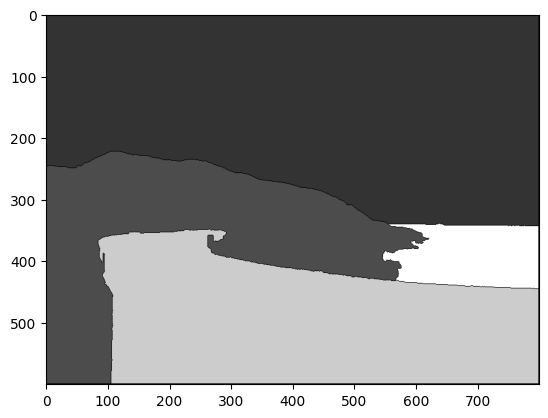

In [73]:
# WHILE TRUE

cv2.namedWindow('Road Image')
cv2.setMouseCallback('Road Image', mouse_callback)

while True:

  cv2.imshow('Watershed Segments',segments)
  cv2.imshow('Road Image', road_copy)
  
  # CLOSE ALL WINDOWS

  k = cv2.waitKey(1)

  if k==27:
    break

  # Clearing all colors press C Key

  elif k==ord('c'):
    road_copy = road.copy()
    marker_image = np.zeros(road.shape[:2],dtype=np.int32)
    segments = np.zeros(road.shape,dtype=np.uint8)

  # UPDATE COLOR CHOICE
  elif k>0 and chr(k).isdigit():
    current_marker = int(chr(k))


  # UPDATE THE MARKINGS
  if marks_updated:

    marker_image_copy = marker_image.copy()
    # Passing a copy to watershed algorithym to work on
    cv2.watershed(road,marker_image_copy)

    segments = np.zeros(road.shape,dtype=np.uint8)

    for color_ind in range(n_markers):
      # COLORING SEGMENTS, NUMPY CALL
      segments[marker_image_copy==(color_ind)] = colors[color_ind]

    marks_updated = False

    plt.imshow(marker_image_copy,cmap='gray')
  

cv2.destroyAllWindows()